**Obsective:**
 Analyze the impact of country, region, date, virus strain, transmission type, and exposure source on disease cases.Develop a model to study and predict case trends.

In [1]:
# Numerical libraries
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing libraries
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Train test split
from sklearn.model_selection import train_test_split

# SVM model
from sklearn.svm import SVC

# Evaluation metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [2]:
from google.colab import files
df = files.upload()

#Read exel file
df = pd.read_csv('ML-CaseStudy3-Dataset.csv')
# Display first  rows
df.head()

Saving ML-CaseStudy3-Dataset.csv to ML-CaseStudy3-Dataset.csv


,case_id,country,region,report_date,virus_strain,transmission_type,exposure_source,patient_age,gender,symptoms,hospitalization,fatality,recovery_days,temperature_celsius,humidity_percent,rodent_presence_index,quarantine_days,population_density,air_quality_index
0,HV2026_00001,Canada,Lake Rickyside,24-11-2025,Sin Nombre,Rodent-to-Human,Agricultural Exposure,26,Male,"Headache, Vomiting, Fever",Yes,No,22.0,27.0,78.9,7,1,538,67
1,HV2026_00002,Bolivia,East Crystal,22-04-2025,Sin Nombre,Human-to-Human,Home Infestation,41,Female,"Fever, Muscle Pain, Fatigue",Yes,No,41.0,23.2,70.9,3,13,5624,162
2,HV2026_00003,Chile,Rossmouth,21-03-2025,Seoul,Human-to-Human,Home Infestation,39,Female,"Fever, Muscle Pain, Fatigue",No,No,31.0,22.6,38.5,8,17,2095,213
3,HV2026_00004,Argentina,West Ryan,10-02-2025,Sin Nombre,Human-to-Human,Rodent Exposure,49,Male,"Fever, Muscle Pain, Fatigue",No,No,11.0,22.6,87.0,7,8,7478,206
4,HV2026_00005,Chile,Mariaberg,25-03-2025,Dobrava,Rodent-to-Human,Home Infestation,59,Male,"Fever, Cough, Headache",No,No,24.0,33.5,36.2,8,12,4472,132


In [3]:
# Shape of dataset
print(df.shape)

# Column names
print(df.columns)

# Dataset information
print(df.info())

# Statistical summary
print(df.describe())

(2000, 19)
Index(['case_id', 'country', 'region', 'report_date', 'virus_strain',
       'transmission_type', 'exposure_source', 'patient_age', 'gender',
       'symptoms', 'hospitalization', 'fatality', 'recovery_days',
       'temperature_celsius', 'humidity_percent', 'rodent_presence_index',
       'quarantine_days', 'population_density', 'air_quality_index'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                2000 non-null   object 
 1   country                2000 non-null   object 
 2   region                 2000 non-null   object 
 3   report_date            2000 non-null   object 
 4   virus_strain           2000 non-null   object 
 5   transmission_type      2000 non-null   object 
 6   exposure_source        2000 non-null   object 
 7   patient_age            2000 non-n

In [4]:
# Check null values
print(df.isnull().sum())

case_id                    0
country                    0
region                     0
report_date                0
virus_strain               0
transmission_type          0
exposure_source            0
patient_age                0
gender                     0
symptoms                   0
hospitalization            0
fatality                   0
recovery_days            155
temperature_celsius        0
humidity_percent           0
rodent_presence_index      0
quarantine_days            0
population_density         0
air_quality_index          0
dtype: int64


In [5]:
df.duplicated().any()

np.False_

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df[df.duplicated()]

,case_id,country,region,report_date,virus_strain,transmission_type,exposure_source,patient_age,gender,symptoms,hospitalization,fatality,recovery_days,temperature_celsius,humidity_percent,rodent_presence_index,quarantine_days,population_density,air_quality_index


In [8]:
data1 = df.drop_duplicates()

In [9]:
df.duplicated().any()

np.False_

In [10]:
data1.shape

(2000, 19)

In [11]:
#Indexing columns
df = data1.isnull().sum().reset_index()
#Rename column
df.columns = ['column', 'null_records']
#Create new colums and Find out null value percentage
df['% null records'] = (df['null_records']/2000*100)
df

,column,null_records,% null records
0,case_id,0,0.00
1,country,0,0.00
2,region,0,0.00
3,report_date,0,0.00
4,virus_strain,0,0.00
5,transmission_type,0,0.00
6,exposure_source,0,0.00
7,patient_age,0,0.00
8,gender,0,0.00
9,symptoms,0,0.00


In [12]:
 data1.columns.str.strip()

Index(['case_id', 'country', 'region', 'report_date', 'virus_strain',
       'transmission_type', 'exposure_source', 'patient_age', 'gender',
       'symptoms', 'hospitalization', 'fatality', 'recovery_days',
       'temperature_celsius', 'humidity_percent', 'rodent_presence_index',
       'quarantine_days', 'population_density', 'air_quality_index'],
      dtype='object')

In [14]:
print(data1.columns)

Index(['case_id', 'country', 'region', 'report_date', 'virus_strain',
       'transmission_type', 'exposure_source', 'patient_age', 'gender',
       'symptoms', 'hospitalization', 'fatality', 'recovery_days',
       'temperature_celsius', 'humidity_percent', 'rodent_presence_index',
       'quarantine_days', 'population_density', 'air_quality_index'],
      dtype='object')


In [15]:
recovery_days_mean = data1['recovery_days'].mean()
recovery_days_mean
data1['recovery_days'] = data1['recovery_days'].fillna(recovery_days_mean)

In [16]:
data1.isnull().sum()

,0
case_id,0
country,0
region,0
report_date,0
virus_strain,0
transmission_type,0
exposure_source,0
patient_age,0
gender,0
symptoms,0


In [17]:
print(data1.columns)

Index(['case_id', 'country', 'region', 'report_date', 'virus_strain',
       'transmission_type', 'exposure_source', 'patient_age', 'gender',
       'symptoms', 'hospitalization', 'fatality', 'recovery_days',
       'temperature_celsius', 'humidity_percent', 'rodent_presence_index',
       'quarantine_days', 'population_density', 'air_quality_index'],
      dtype='object')


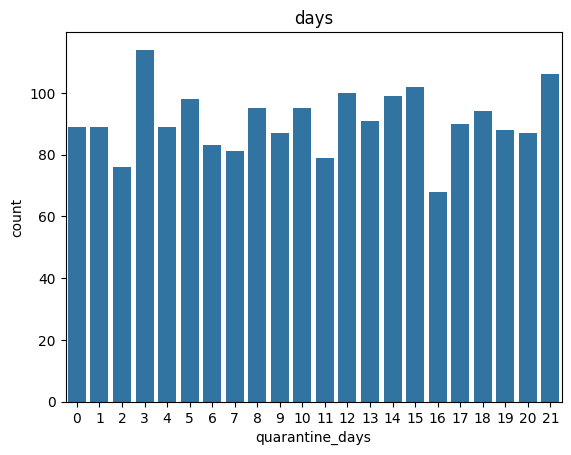

In [18]:
sns.countplot(x='quarantine_days', data=data1)

plt.title("days")

plt.show()

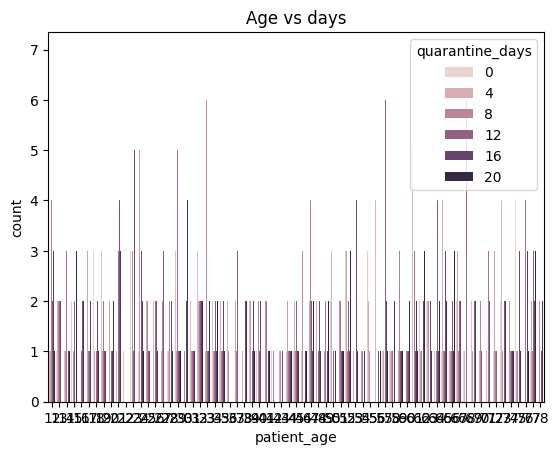

In [19]:
sns.countplot(x='patient_age',
              hue='quarantine_days',
              data=data1)

plt.title("Age vs days")

plt.show()

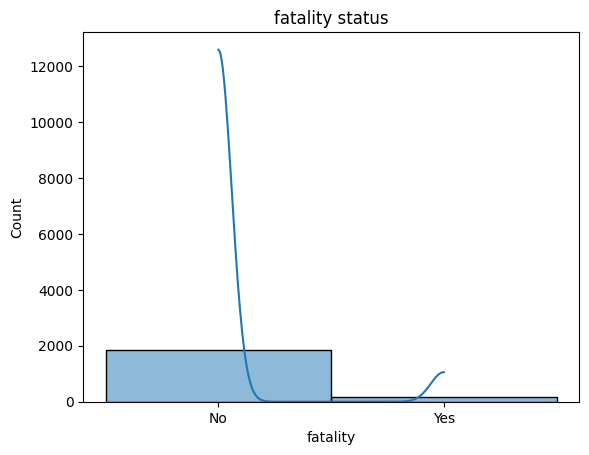

In [20]:
sns.histplot(data1['fatality'],
             bins=20,
             kde=True)

plt.title("fatality status")

plt.show()

In [21]:
Categorical_col = data1.select_dtypes(include = 'object').columns
Categorical_col

Index(['case_id', 'country', 'region', 'report_date', 'virus_strain',
       'transmission_type', 'exposure_source', 'gender', 'symptoms',
       'hospitalization', 'fatality'],
      dtype='object')

In [22]:
le = LabelEncoder()

data1['case_id'] = le.fit_transform(data1['case_id'])
data1['country'] = le.fit_transform(data1['country'])
data1['region'] = le.fit_transform(data1['region'])
data1['report_date'] = le.fit_transform(data1['report_date'])
data1['virus_strain'] = le.fit_transform(data1['virus_strain'])
data1['transmission_type'] = le.fit_transform(data1['transmission_type'])
data1['exposure_source'] = le.fit_transform(data1['exposure_source'])
data1['gender'] = le.fit_transform(data1['gender'])
data1['symptoms'] = le.fit_transform(data1['symptoms'])
data1['hospitalization'] = le.fit_transform(data1['hospitalization'])
data1['fatality'] = le.fit_transform(data1['fatality'])

In [23]:
X = data1[['country',
        'region',
        'report_date',
        'virus_strain',
        'transmission_type',
        'exposure_source']]


y = data1['case_id']

In [24]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

svm_model = SVC(
    kernel='linear',
    C=1
)

svm_model.fit(X_train, y_train)

SVC(C=1, kernel='linear')

In [25]:
y_pred = svm_model.predict(X_test)

print(y_pred)

[1973  625 1793  706 1493 1020 1366 1200  805 1128 1702  750 1694   35
 1270  130 1183 1446  838  972 1569 1722  791 1694 1770 1216  972 1253
  415 1639  814  574 1526  691 1757 1065  619 1415   15 1094  501 1904
  309  577  528 1212 1202  645  565  118 1163   17 1690  853 1436  165
  198 1056  151  426 1588    1 1622  663  813 1441  321  169 1683 1565
 1482 1115  988 1455 1694  595  138  318  877 1703 1899  197 1028   24
  644  295 1306 1373  866 1946 1413 1844  143  861  477 1772   19  928
 1858 1248 1679   15 1322 1548 1627  870  229   21  229 1478   46 1634
  556  430 1879  865  989 1650  589  553    7 1977 1622 1571  511  129
 1871 1320 1493 1733 1167  151  356   19  626 1907 1859  589  522  713
 1059 1498  971 1980 1235  660 1307  253 1151 1062 1138  116  447  110
  935  908 1126 1180  102  465 1596 1689  469  927 1896  250 1995  830
  392 1236 1845 1216  565  164 1712 1359 1267 1087  961 1671 1763    3
 1949  195  877  988   15  508 1732 1250  798 1971 1462 1826  739 1316
  187 

In [26]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.0


[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


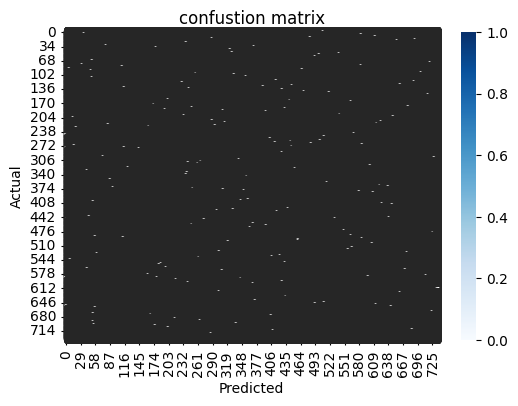

In [27]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

plt.figure(figsize=(6,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("confustion matrix")
plt.show()

In [28]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.00      0.00      0.00       0.0
           3       0.00      0.00      0.00       0.0
           7       0.00      0.00      0.00       0.0
           8       0.00      0.00      0.00       0.0
          10       0.00      0.00      0.00       0.0
          15       0.00      0.00      0.00       0.0
          17       0.00      0.00      0.00       0.0
          19       0.00      0.00      0.00       0.0
          21       0.00      0.00      0.00       0.0
          23       0.00      0.00      0.00       1.0
          24       0.00      0.00      0.00       0.0
          28       0.00      0.00      0.00       0.0
          29       0.00      0.00      0.00       1.0
          30       0.00      0.00      0.00       1.0
          32       0.00      0.00      0.00       1.0
          35       0.00      0.00      0.00       0.0
          44       0.00      0.00      0.00       1.0
          45       0.00    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [29]:
svm_rbf = SVC(
    kernel='rbf',
    C=1,
    gamma='scale'
)

svm_rbf.fit(X_train, y_train)

rbf_pred = svm_rbf.predict(X_test)

print("RBF Accuracy:",
      accuracy_score(y_test, rbf_pred))

RBF Accuracy: 0.0


In [30]:
svm_rbf.fit(X_train, y_train)

rbf_pred = svm_rbf.predict(X_test)

print("RBF Accuracy:",
      accuracy_score(y_test, rbf_pred))

svm_poly = SVC(
    kernel='poly',
    degree=3
)

svm_poly.fit(X_train, y_train)

poly_pred = svm_poly.predict(X_test)

print("Polynomial Accuracy:",
      accuracy_score(y_test, poly_pred))

RBF Accuracy: 0.0
Polynomial Accuracy: 0.0


**Conclusion:**

The Support Vector Machine (SVM) model did not perform effectively on this dataset, achieving an accuracy of 0.0 for both the RBF and Polynomial kernels. The confusion matrix and classification report indicate that the model was unable to correctly classify any instances, resulting in precision, recall, and F1-scores of 0.00. These results suggest that the data may require further preprocessing, feature engineering, class balancing, or parameter tuning. Overall, the current SVM model is not suitable for accurate prediction on this dataset, and alternative models or optimization techniques should be explored to improve performance.